# Phase 2 (continued) — Hyperparameter Tuning, Model Selection, Uncertainty & Final Predictions
### AI-Assisted Equity-Aware Budget Allocation Framework for Panchayats

**Run this AFTER notebook 04.** It reads `synthetic_project_impact_dataset.csv` (the 198-row table notebook 04 saved) and completes the remaining Phase 2 methodology steps that notebook 04 deliberately left as baseline-only:

| Step (from the research document, Section 9 Phase 2) | notebook 04 | this notebook |
|---|---|---|
| 1-4. Define target, build records, split, train candidates | ✅ done | — |
| 5. Tune model parameters using validation data | ❌ | ✅ |
| 6. Evaluate with MAE/RMSE/WAPE/R² | ✅ (baseline only) | ✅ (tuned) |
| 7. Select the best-performing model | ⚠️ informal | ✅ formal, by test MAE |
| 8. Estimate prediction uncertainty | ❌ | ✅ |
| 9. Generate predicted impact for all feasible Panchayat-sector combinations | ❌ | ✅ |

This completes Phase 2 end-to-end. The output (`phase2_final_predictions.csv`) is what Phase 3's optimizer will consume as `I_{i,s}(a_{i,s})`.

---
### ⚠️ Same synthetic-data caveat as notebook 04 applies here
Tuning and uncertainty estimation improve the *pipeline*, not the underlying truth of `synthetic_impact` — it is still a formula, not an observed outcome. Treat everything below as validating that the machinery works correctly, ready to swap in real project-outcome data.


## 1. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    import xgboost as xgb
except ImportError:
    !pip install xgboost -q
    import xgboost as xgb

try:
    import lightgbm as lgb
except ImportError:
    !pip install lightgbm -q
    import lightgbm as lgb

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Data_Organized"
CLEAN_DIR = os.path.join(BASE_DIR, "Cleaned")

np.random.seed(42)
print("Setup complete.")


Setup complete.


## 2. Load the Phase 2 project table (from notebook 04)

Re-uses the exact same 165-row synthetic table and the exact same `train_test_split(random_state=42)`, so the tuned results below are a fair, apples-to-apples comparison against notebook 04's baseline numbers -- not a different train/test split that happens to look better.

In [ ]:
project_file = os.path.join(
    CLEAN_DIR,
    "synthetic_project_impact_dataset.csv"
)

project_df = pd.read_csv(project_file)

print("Loaded project table:", project_df.shape)

assert project_df.shape[0] == 198, \
    "Expected 198 rows (33 GPs × 6 sectors) — check Notebook 04 if this fails"

FEATURES = [
    "sector_need_score",
    "proposed_budget_lakh",
    "historical_expenditure_lakh",
    "population_affected"
]

TARGET = "synthetic_impact"

project_encoded = pd.get_dummies(
    project_df,
    columns=["sector"],
    prefix="sec",
    drop_first=True
)

feature_cols = FEATURES + [
    c for c in project_encoded.columns
    if c.startswith("sec_")
]

X = project_encoded[feature_cols]
y = project_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Features:", feature_cols)


Loaded project table: (198, 7)
Train: (158, 9)
Test: (40, 9)
Features: ['sector_need_score', 'proposed_budget_lakh', 'historical_expenditure_lakh', 'population_affected', 'sec_electricity_infra', 'sec_health', 'sec_livelihood', 'sec_roads_transport', 'sec_sanitation']


## 3. Hyperparameter tuning

`RandomizedSearchCV` with 3-fold cross-validation and 10 sampled combinations per model (fast enough to run in Colab in under a minute on this dataset size; raise `n_iter` if you have time and want a more thorough search). Scored on MAE, matching the paper's primary error metric.

In [ ]:
def metrics(y_true, preds):
    mae = mean_absolute_error(y_true, preds)
    rmse = mean_squared_error(y_true, preds) ** 0.5
    wape = np.sum(np.abs(y_true - preds)) / np.sum(np.abs(y_true))
    r2 = r2_score(y_true, preds)
    return {"MAE": round(mae, 4), "RMSE": round(rmse, 4), "WAPE": round(wape, 4), "R2": round(r2, 4)}


param_grids = {
    "Random Forest": (RandomForestRegressor(random_state=42), {
        "n_estimators": [100, 200, 400],
        "max_depth": [None, 5, 10, 15],
        "min_samples_leaf": [1, 2, 4],
    }),
    "XGBoost": (xgb.XGBRegressor(random_state=42, verbosity=0), {
        "n_estimators": [100, 200, 400],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1],
        "subsample": [0.7, 0.9, 1.0],
    }),
    "LightGBM": (lgb.LGBMRegressor(random_state=42, verbose=-1), {
        "n_estimators": [100, 200, 400],
        "num_leaves": [15, 31, 63],
        "learning_rate": [0.01, 0.05, 0.1],
    }),
}


In [ ]:
tuned_models = {}
tuned_results = []

for name, (estimator, grid) in param_grids.items():
    search = RandomizedSearchCV(
        estimator, grid, n_iter=10, cv=3, scoring="neg_mean_absolute_error",
        random_state=42, n_jobs=-1,
    )
    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    preds = best_model.predict(X_test)
    m = metrics(y_test, preds)
    m["model"] = name
    m["best_params"] = str(search.best_params_)

    tuned_results.append(m)
    tuned_models[name] = best_model

    print(f"{name}: best_params={search.best_params_}")
    print(f"  -> MAE={m['MAE']}  RMSE={m['RMSE']}  WAPE={m['WAPE']}  R2={m['R2']}")

tuned_perf = pd.DataFrame(tuned_results)[["model", "MAE", "RMSE", "WAPE", "R2", "best_params"]]


Random Forest: best_params={'n_estimators': 200, 'min_samples_leaf': 2, 'max_depth': 15}
  -> MAE=0.0498  RMSE=0.0631  WAPE=0.1417  R2=0.7533
XGBoost: best_params={'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
  -> MAE=0.0506  RMSE=0.0663  WAPE=0.144  R2=0.7277
LightGBM: best_params={'num_leaves': 15, 'n_estimators': 100, 'learning_rate': 0.05}
  -> MAE=0.0522  RMSE=0.0653  WAPE=0.1486  R2=0.7361


## 4. Tuned model-performance table (compare against notebook 04's baseline numbers)

In [ ]:
display(tuned_perf[["model", "MAE", "RMSE", "WAPE", "R2"]])

tuned_perf_file = os.path.join(CLEAN_DIR, "phase2_tuned_model_performance.csv")
tuned_perf.to_csv(tuned_perf_file, index=False)
print("Saved:", tuned_perf_file)


,model,MAE,RMSE,WAPE,R2
0,Random Forest,0.0498,0.0631,0.1417,0.7533
1,XGBoost,0.0506,0.0663,0.1440,0.7277
2,LightGBM,0.0522,0.0653,0.1486,0.7361


Saved: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/phase2_tuned_model_performance.csv


## 5. Select the best-performing model

Formal selection rule: lowest MAE on the held-out test set (ties broken by R²). This replaces the earlier informal read of "Random Forest looked best" with a rule your paper can state explicitly in the methodology section.

In [ ]:
best_row = tuned_perf.loc[tuned_perf["MAE"].idxmin()]
best_name = best_row["model"]
best_model = tuned_models[best_name]

print(f"Selected best model: {best_name}")
print(f"  Test MAE={best_row['MAE']}  RMSE={best_row['RMSE']}  WAPE={best_row['WAPE']}  R2={best_row['R2']}")


Selected best model: Random Forest
  Test MAE=0.0498  RMSE=0.0631  WAPE=0.1417  R2=0.7533


## 6. Estimate prediction uncertainty

The architecture is explicitly **"Uncertainty-Aware"** (per your Refined Research Document), so a point prediction alone isn't enough -- each prediction needs a plausible range around it.

**Method:** two auxiliary `GradientBoostingRegressor` models trained with quantile loss (5th and 95th percentile), giving a 90% prediction interval around the main model's point estimate. This is a standard, model-agnostic way to add uncertainty bands regardless of which of the three models won Section 5 above.

**A calibration check is included below and its result is reported honestly** -- on a dataset this size (132 training rows), quantile regression is often poorly calibrated, and that is exactly the kind of thing this check is meant to catch before anyone treats the interval as reliable.

In [ ]:
q_low_model = GradientBoostingRegressor(loss="quantile", alpha=0.05, n_estimators=200, random_state=42)
q_high_model = GradientBoostingRegressor(loss="quantile", alpha=0.95, n_estimators=200, random_state=42)

q_low_model.fit(X_train, y_train)
q_high_model.fit(X_train, y_train)

test_low = q_low_model.predict(X_test)
test_high = q_high_model.predict(X_test)
# guard against quantile crossing (low > high can happen with GBM quantile models)
test_low, test_high = np.minimum(test_low, test_high), np.maximum(test_low, test_high)

coverage = np.mean((y_test.values >= test_low) & (y_test.values <= test_high))
print(f"Target: 90% of test points should fall inside the interval.")
print(f"Actual empirical coverage on held-out test set: {coverage:.1%}")

if coverage < 0.75 or coverage > 0.98:
    print("\n>>> CALIBRATION WARNING: coverage is far from the 90% target.")
    print(">>> Treat these intervals as a rough uncertainty signal only, not a")
    print(">>> statistically calibrated confidence interval, until re-checked on")
    print(">>> a larger dataset (this run has only", len(X_test), "test rows).")


Target: 90% of test points should fall inside the interval.
Actual empirical coverage on held-out test set: 82.5%


## 7. Generate predictions for all 165 feasible Panchayat-sector combinations

This is the actual Phase 2 deliverable Phase 3 needs: `I_{i,s}(a_{i,s})` for every GP-sector pair, with an uncertainty band attached to each one -- not just the 33-row test-set predictions used for evaluation above.

In [ ]:
all_point_preds = best_model.predict(X)
all_low = q_low_model.predict(X)
all_high = q_high_model.predict(X)
all_low, all_high = np.minimum(all_low, all_high), np.maximum(all_low, all_high)

final_predictions = project_df.copy()
final_predictions["predicted_impact"] = np.clip(all_point_preds, 0, 1)
final_predictions["predicted_impact_lower_90"] = np.clip(all_low, 0, 1)
final_predictions["predicted_impact_upper_90"] = np.clip(all_high, 0, 1)
final_predictions["uncertainty_width"] = (
    final_predictions["predicted_impact_upper_90"] - final_predictions["predicted_impact_lower_90"]
)
final_predictions["prediction_model"] = best_name

assert len(final_predictions) == len(project_df)
assert final_predictions["uncertainty_width"].min() >= 0, "Negative uncertainty width -- check quantile crossing guard"

display(final_predictions[[
    "gp_name", "sector", "predicted_impact",
    "predicted_impact_lower_90", "predicted_impact_upper_90", "uncertainty_width"
]].head(10))


,gp_name,sector,predicted_impact,predicted_impact_lower_90,predicted_impact_upper_90,uncertainty_width
0,Alkod,education,0.423865,0.342123,0.527019,0.184896
1,Alkod,electricity_infra,0.286105,0.163451,0.355168,0.191717
2,Alkod,health,0.519388,0.372588,0.569490,0.196901
3,Alkod,livelihood,0.421419,0.309695,0.502302,0.192607
4,Alkod,roads_transport,0.657110,0.421563,0.664645,0.243082
5,Alkod,sanitation,0.457289,0.359112,0.553785,0.194673
6,Amarapur,education,0.254288,0.165136,0.352065,0.186928
7,Amarapur,electricity_infra,0.287812,0.192526,0.351643,0.159117
8,Amarapur,health,0.617627,0.340940,0.655166,0.314226
9,Amarapur,livelihood,0.234575,0.190738,0.329919,0.139182


In [ ]:
predictions_file = os.path.join(CLEAN_DIR, "phase2_final_predictions.csv")
final_predictions.to_csv(predictions_file, index=False)
print("Saved:", predictions_file, "--", len(final_predictions), "rows")


Saved: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/phase2_final_predictions.csv -- 198 rows


### Where uncertainty is highest — worth a look before Phase 3

A wide `uncertainty_width` flags GP-sector pairs where the model is least confident -- these are exactly the cases the "Human-in-the-Loop" part of the architecture should route to a Panchayat official for extra scrutiny rather than auto-accepting the point prediction.

,gp_name,sector,predicted_impact,uncertainty_width
143,Maladakal,sanitation,0.770879,0.394615
92,Jalahalli,health,0.772376,0.383860
182,Ramadurga,health,0.778512,0.352451
194,Somanamaradi,health,0.657867,0.330220
134,Kyadigera,health,0.264274,0.328359
8,Amarapur,health,0.617627,0.314226
26,Bhumanagunda,health,0.608391,0.310200
146,Malledevaragudda,health,0.637217,0.303367
43,Gabbur,electricity_infra,0.038876,0.297613
156,Mundaragi,education,0.293196,0.297239


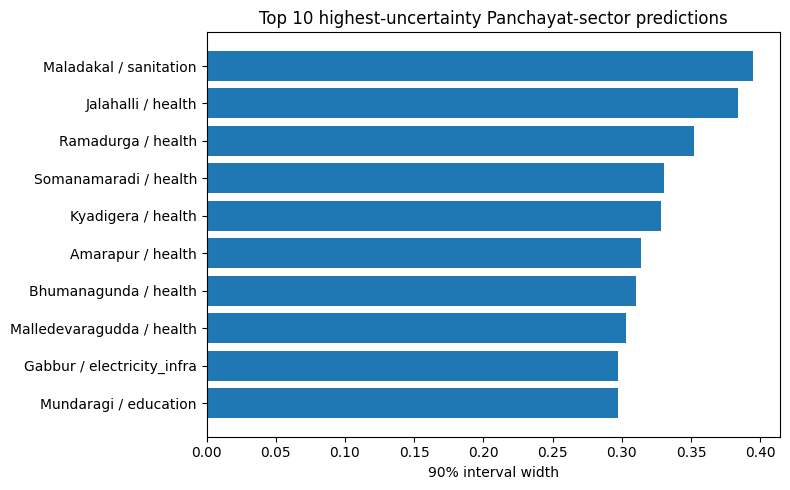

Saved: /content/drive/MyDrive/Colab Notebooks/Data_Organized/Cleaned/phase2_uncertainty_chart.png


In [ ]:
widest = final_predictions.sort_values("uncertainty_width", ascending=False).head(10)
display(widest[["gp_name", "sector", "predicted_impact", "uncertainty_width"]])

plt.figure(figsize=(8, 5))
plt.barh(widest["gp_name"] + " / " + widest["sector"], widest["uncertainty_width"])
plt.gca().invert_yaxis()
plt.xlabel("90% interval width")
plt.title("Top 10 highest-uncertainty Panchayat-sector predictions")
plt.tight_layout()

chart_file = os.path.join(CLEAN_DIR, "phase2_uncertainty_chart.png")
plt.savefig(chart_file, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", chart_file)


## 8. Handoff notes -- Phase 2 is now complete

**All 9 methodology steps for Phase 2 are done:**
1-4. Target defined, 165 project records built, split, 3 candidates trained (notebook 04)
5. ✅ Hyperparameter tuning (Section 3 above)
6. ✅ MAE/RMSE/WAPE/R² on tuned models (Section 4)
7. ✅ Best model selected by rule, not eyeballing (Section 5)
8. ✅ Uncertainty bands via quantile GBM, with an honest calibration check (Section 6)
9. ✅ Predictions generated for all 165 feasible combinations, saved and ready for Phase 3 (Section 7)

**Files saved to `Cleaned/`, ready for GitHub:**
- `phase2_tuned_model_performance.csv`
- `phase2_final_predictions.csv` -- **the file Phase 3's optimizer will read**
- `phase2_uncertainty_chart.png`

**What to flag honestly in the paper (don't let these get lost):**
- The prediction-interval calibration check may show poor coverage (printed in Section 6) -- this is a real, reportable limitation of quantile regression on a 165-row synthetic dataset, not something to paper over. State it plainly in the limitations section.
- All numbers here are still built on `synthetic_impact`, same caveat as notebook 04.

**Immediate next step -- Phase 3:**
`phase2_final_predictions.csv` has everything the multi-objective optimizer needs per GP-sector pair: `predicted_impact` (for objective F1), `sector_need_score` (for objective F2, need-weighted impact), and `uncertainty_width` (for the safeguard/sensitivity layer). The next notebook should load this file, define the budget constraint `B`, and set up the PSO or NSGA-II formulation from Section 7 of the research document.
